# In this notebook we explore the performance of GNN on a subgraph of a specific material.
In this case we chosed YSZ to be the subject due to its relative larger dataset.
We hope to see that the model learns the relationships between induced electric field and flash onset values for YSZ

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scripts.gnn import KneePointGCN, train, visualize_graph, plot_losses

load data and create feature matrix

**Dataset trains only on YSZ Subgraphs**

In [2]:
data_df = pd.read_csv('FlashSintering/data/master_dataframe.csv')
data_df = data_df.query('Material == "YSZ"')

node_features = []
node_labels = []

data_df = data_df.sort_values('Electric_Field(V/cm)').reset_index(drop=True)

data_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']] = data_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']].round({'Knee_Temp(1000/T)': 3, 'Knee_PW(mW/mm^3)': 0})

print(data_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']])
node_features = data_df[['Electric_Field(V/cm)']].values
    
node_labels = data_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']].values
    
print(node_features)
print(node_labels)


    Knee_Temp(1000/T)  Knee_PW(mW/mm^3)
0               1.089              33.0
1               1.184              28.0
2               1.225              48.0
3               1.293              36.0
4               1.328              36.0
5               1.345              33.0
6               1.347              46.0
7               1.392              44.0
8               1.410              36.0
9               1.427              32.0
10              1.585              21.0
11              1.613              35.0
12              1.614              32.0
13              1.654              31.0
14              1.666              39.0
15              1.684              42.0
16              1.693              38.0
17              1.702              28.0
[[ 50.]
 [ 70.]
 [ 90.]
 [130.]
 [150.]
 [170.]
 [190.]
 [210.]
 [230.]
 [250.]
 [290.]
 [370.]
 [390.]
 [410.]
 [430.]
 [450.]
 [470.]
 [490.]]
[[ 1.089 33.   ]
 [ 1.184 28.   ]
 [ 1.225 48.   ]
 [ 1.293 36.   ]
 [ 1.328 36.   ]
 [ 1.345 3

split dataset into train, validation and test dataset (64,16,20) and normalize

In [3]:
train_features, test_features, train_labels, test_labels = train_test_split(node_features, node_labels, test_size=0.2, shuffle=True, random_state=42)
train_features, val_features, train_labels, val_labels = train_test_split(train_features, train_labels, test_size=0.2, shuffle=True, random_state=42)

scaler = MinMaxScaler()
scaler.fit(train_features[:, -1].reshape(-1, 1))

train_features[:, -1] = scaler.transform(train_features[:, -1].reshape(-1, 1)).ravel()
val_features[:, -1]   = scaler.transform(val_features[:, -1].reshape(-1, 1)).ravel()
test_features[:, -1]  = scaler.transform(test_features[:, -1].reshape(-1, 1)).ravel()

train_features = torch.from_numpy(train_features).float()
train_labels   = torch.from_numpy(train_labels).float()

val_features   = torch.from_numpy(val_features).float()
val_labels     = torch.from_numpy(val_labels).float()

test_features  = torch.from_numpy(test_features).float()
test_labels    = torch.from_numpy(test_labels).float()

In this case due to lack of available data, a fully connected graph construction is constructed

In [4]:
train_edges = []
test_edges = []
val_edges = []

# create train_edges_index
for i in range(len(train_features)):
    for j in range(i + 1, len(train_features)):
        train_edges.append([i, j])

for i in range(len(test_features)):
    for j in range(i + 1, len(test_features)):
        test_edges.append([i, j])

for i in range(len(val_features)):
    for j in range(i + 1, len(val_features)):
        val_edges.append([i, j])

train_edges  = to_undirected(torch.tensor(train_edges).t())
test_edges = to_undirected(torch.tensor(test_edges).t())
val_edges = to_undirected(torch.tensor(val_edges).t())
print(train_edges)
print(test_edges)
print(val_edges)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,
          3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,
          5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,
          7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
          9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10,
         10, 10],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  2,  3,  4,  5,  6,  7,  8,
          9, 10,  0,  1,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,  4,  5,  6,
          7,  8,  9, 10,  0,  1,  2,  3,  5,  6,  7,  8,  9, 10,  0,  1,  2,  3,
          4,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  7,  8,  9, 10,  0,  1,
          2,  3,  4,  5,  6,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  9, 10,
          0,  1,  2,  3,  4,  5,  6,  7,  8, 10,  0,  1,  2,  3,  4,  5,  6,  7,
          

Create train test validation dataloader

In [5]:
train_data = Data(x=train_features, edge_index=train_edges, y=train_labels)
val_data = Data(x=val_features, edge_index=val_edges, y=val_labels)
test_data = Data(x=test_features, edge_index=test_edges, y= test_labels)

Visualize the constructed graph

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


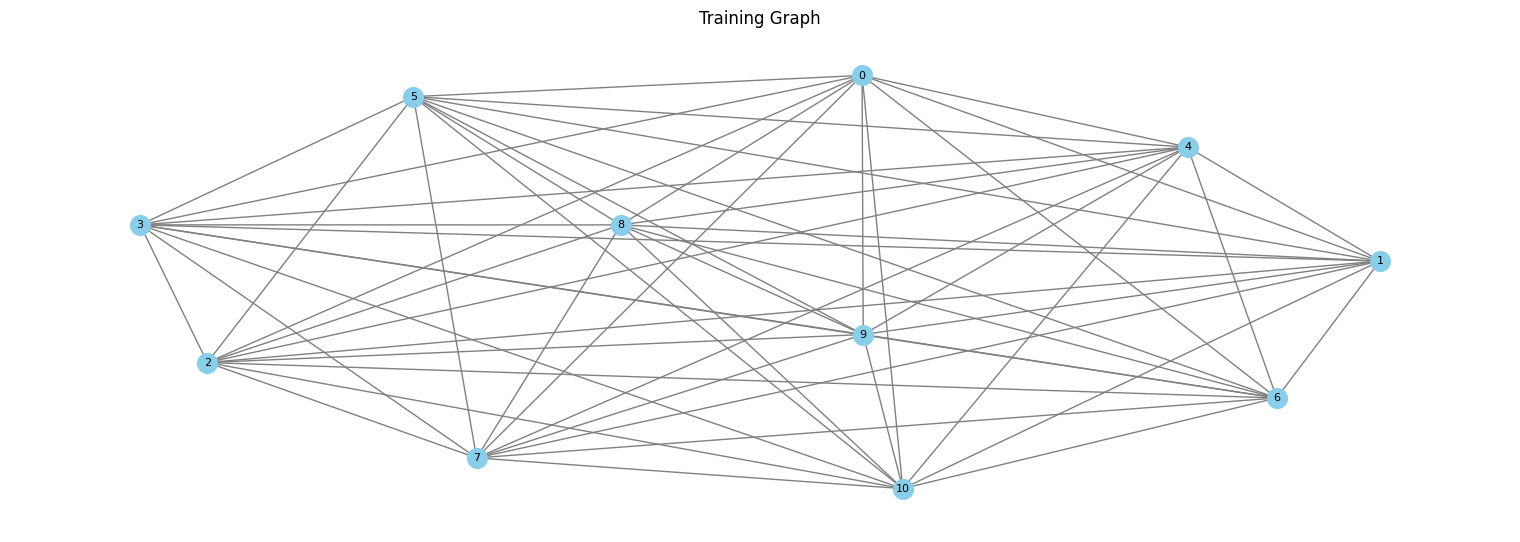

[0, 1, 2, 3]


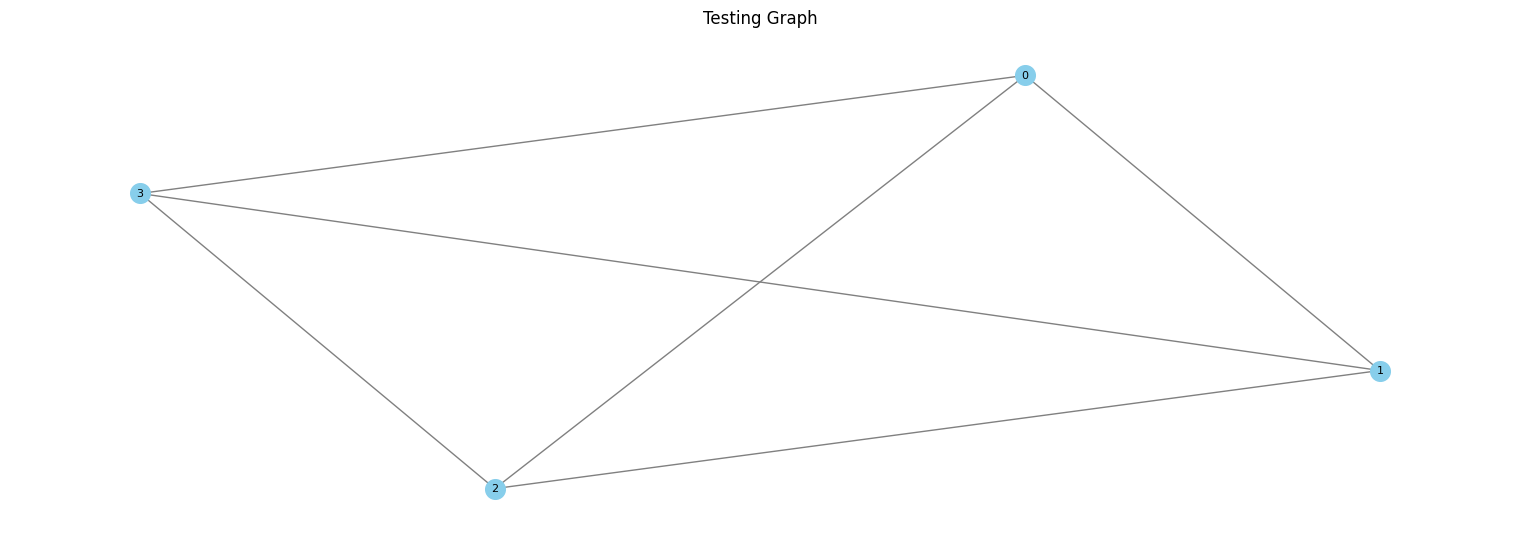

[0, 1, 2]


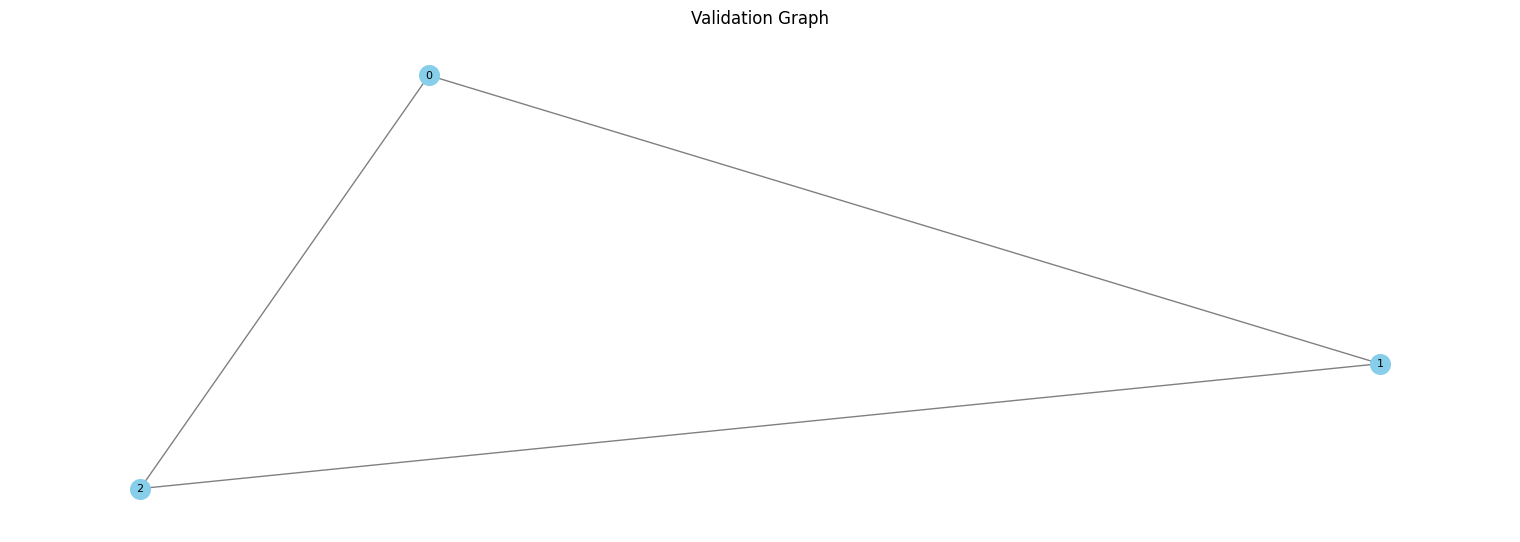

In [6]:
# Visualizing Train Graph
visualize_graph(train_data, title="Training Graph")

# Visualizing Test Graph
visualize_graph(test_data, title="Testing Graph")

visualize_graph(val_data, title="Validation Graph")

## Training and evaluating loss & accuracy

Epoch 1/350, Train Loss: 19.729400634765625, Train Accuracy: 0.5961837768554688%
Val Loss: 15.482559204101562, Val Accuracy: 2.2728805541992188%
Epoch 2/350, Train Loss: 19.696353912353516, Train Accuracy: 2.1172637939453125%
Val Loss: 15.457974433898926, Val Accuracy: 3.296295166015625%
Epoch 3/350, Train Loss: 19.667438507080078, Train Accuracy: 3.329986572265625%
Val Loss: 15.432673454284668, Val Accuracy: 4.334663391113281%
Epoch 4/350, Train Loss: 19.63896942138672, Train Accuracy: 4.481597900390625%
Val Loss: 15.405463218688965, Val Accuracy: 5.461029052734375%
Epoch 5/350, Train Loss: 19.60839080810547, Train Accuracy: 5.720123291015625%
Val Loss: 15.376285552978516, Val Accuracy: 6.659576416015625%
Epoch 6/350, Train Loss: 19.575593948364258, Train Accuracy: 7.038238525390625%
Val Loss: 15.34493350982666, Val Accuracy: 7.934944152832031%
Epoch 7/350, Train Loss: 19.54035758972168, Train Accuracy: 8.441459655761719%
Val Loss: 15.311137199401855, Val Accuracy: 9.293479919433594%


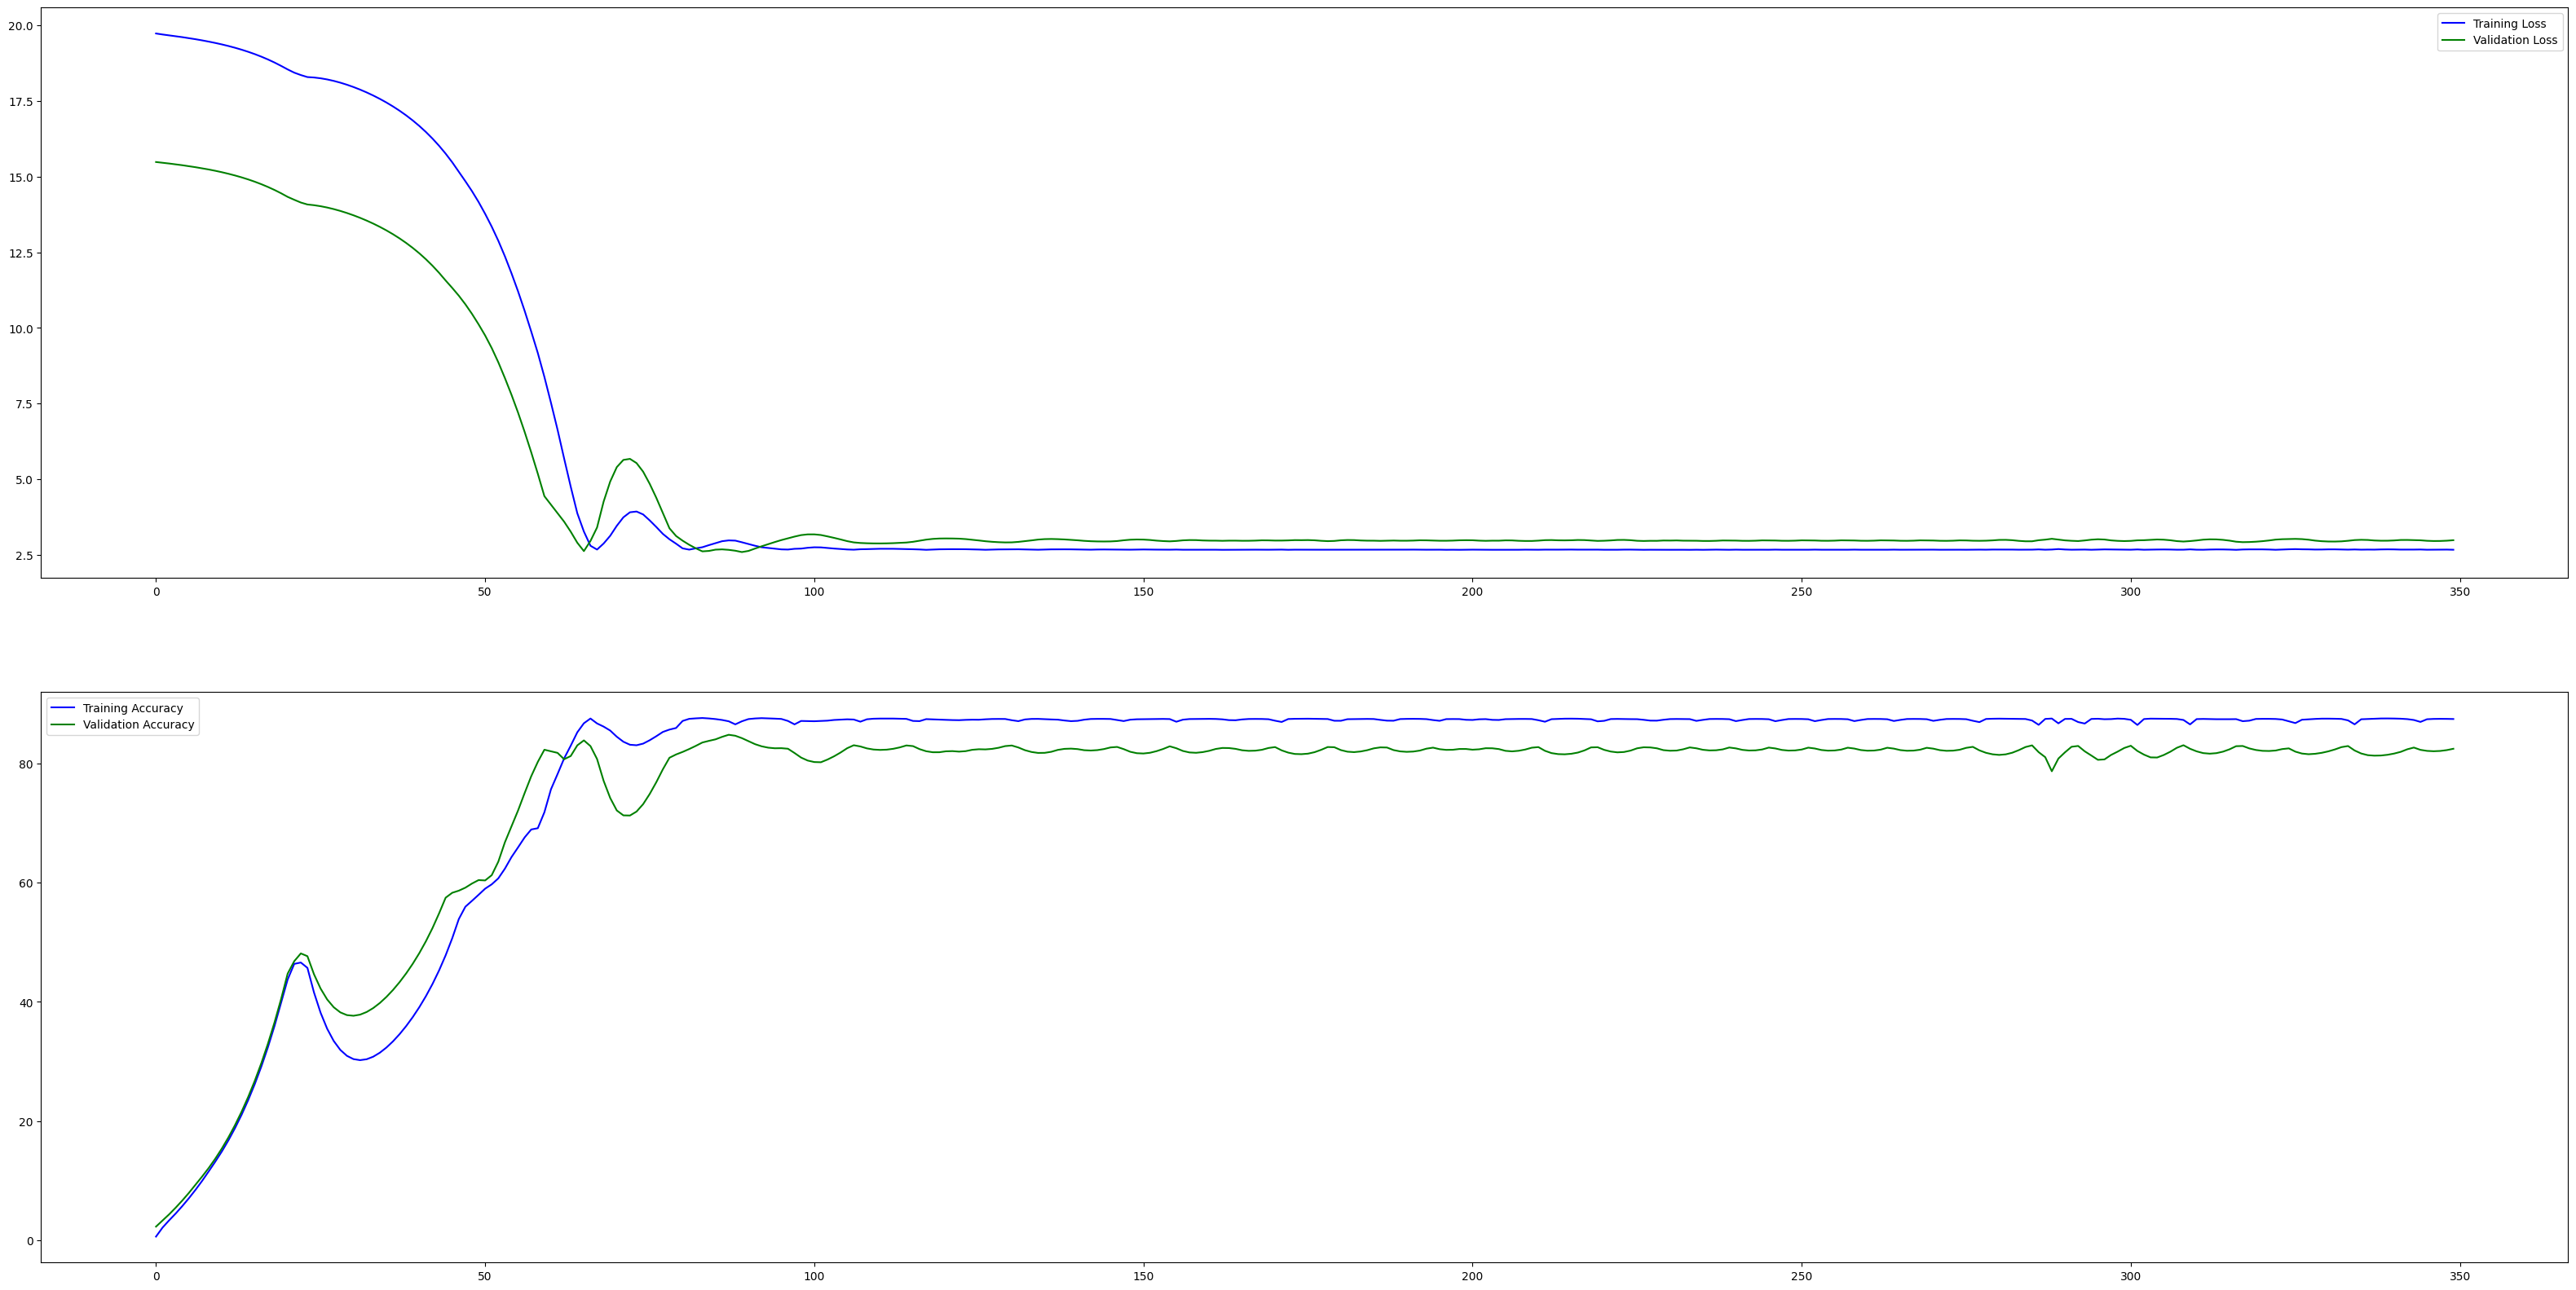

In [7]:
# Train the model
model = KneePointGCN(features=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.L1Loss()
epochs = 350
hist = train(model=model, train_data=train_data, val_data=val_data, test_data=test_data, optimizer=optimizer, loss_fn=loss_fn, epochs=epochs)
plot_losses(training_losses=hist['train_losses'], training_accuracies=hist['train_accuracies'], test_accuracies=hist['test_accuracies'], test_losses=hist['test_losses'], val_accuracies=hist['val_accuracies'], val_losses=hist['val_losses'], epochs=epochs, save_path='/home/sgl57/CSE_MSE_RXF131/cradle-members/mds3/sgl57/24-ceramics-rishi/topics/GNN')